In [20]:
# Installs essential Python libraries used for data analysis, visualization, and machine learning.
# Includes pandas & numpy for data handling, matplotlib & seaborn for visualization, and scikit-learn for ML models.
!pip install pandas numpy matplotlib seaborn scikit-learn

In [21]:
"""
Imports required libraries for data analysis and visualization,
then load the dataset and preview the first few rows.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [22]:
"""
Cleans and transforms the dataset for machine learning by removing unnecessary columns,
creating a useful feature (Car_Age), and converting categorical data into numerical format.
"""
df.drop(['Car_Name'], axis=1, inplace=True)

df['Car_Age'] = 2024 - df['Year']
df.drop(['Year'], axis=1, inplace=True)

df = pd.get_dummies(df, drop_first=True)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,10,False,True,False,True
1,4.75,9.54,43000,0,11,True,False,False,True
2,7.25,9.85,6900,0,7,False,True,False,True
3,2.85,4.15,5200,0,13,False,True,False,True
4,4.60,6.87,42450,0,10,True,False,False,True


In [23]:
# Splits dataset into features (X) and target variable (y)
# X contains input variables, y contains the value we want to predict
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X.head()

,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,5.59,27000,0,10,False,True,False,True
1,9.54,43000,0,11,True,False,False,True
2,9.85,6900,0,7,False,True,False,True
3,4.15,5200,0,13,False,True,False,True
4,6.87,42450,0,10,True,False,False,True


In [24]:
"""
Splits the dataset into training and testing sets.
80% of the data is used for training and 20% for testing the model.
"""
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(240, 8)
(61, 8)


In [25]:
"""
Builds and trains a Random Forest regression model to predict car prices.
The model learns relationships between input features and selling price from training data.
"""
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [26]:
"""
Generates predictions using the trained model on the test dataset.
Displays the first 10 predicted selling prices.
"""
predictions = model.predict(X_test)

predictions[:10]

array([ 0.4337, 11.1038,  4.872 ,  0.2144,  7.3105,  6.3005,  1.0679,
        0.5842,  0.4708,  6.679 ])

In [27]:
"""
Calculates the R2 score to evaluate how well the model predicts selling prices.
A higher R2 value indicates better prediction accuracy.
"""
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, predictions))

R2 Score: 0.9627639770754174


In [28]:
print("Actual Price:", y.iloc[0])
print("Predicted Price:", model.predict(X.iloc[0].values.reshape(1, -1))[0])


Actual Price: 3.35
Predicted Price: 3.797000000000003


c:\Users\HP\anaconda3\envs\py3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


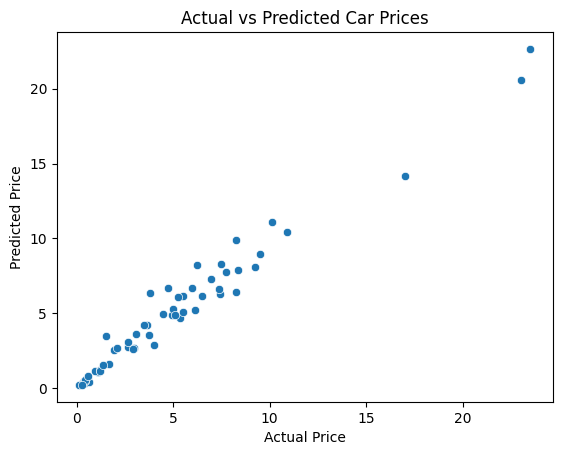

In [29]:
"""
Creates a scatter plot to compare actual prices with predicted prices.
Helps visually evaluate how accurate the model predictions are.
"""
import matplotlib.pyplot as plt

sns.scatterplot(x=y_test, y=predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [30]:
"""
Saves the trained model into a file using joblib.
This allows the model to be reused later without retraining.
"""
import joblib

joblib.dump(model, "car_price_model.pkl")

['car_price_model.pkl']

In [31]:
"""
Loads the saved model and test it by predicting the price for one sample.
Then compare the predicted price with the actual value.
"""
import joblib

loaded_model = joblib.load("car_price_model.pkl")

print("Predicted Price:", loaded_model.predict([X_test.iloc[0]])[0])
print("Actual Price:", y_test.iloc[0])

Predicted Price: 0.43370000000000003
Actual Price: 0.35


c:\Users\HP\anaconda3\envs\py3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
